In [1]:
import os
import random
import copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, f1_score, classification_report, confusion_matrix)

from tqdm import tqdm

def set_seed(seed=0):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(33)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
DATASET_PATH = "/kaggle/input/datasets/subhajournal/busi-breast-ultrasound-images-dataset/Dataset_BUSI_with_GT"
CLASS_NAMES  = ["normal", "benign", "malignant"]

In [3]:
records = []

for cls in CLASS_NAMES:
    folder = os.path.join(DATASET_PATH, cls)
    for fname in os.listdir(folder):
        if fname.endswith(".png") and "_mask" not in fname:
            records.append({"path": os.path.join(folder, fname), "label": cls})

df = pd.DataFrame(records)
print("Total images:", len(df))
df.head()

Total images: 780


,path,label
0,/kaggle/input/datasets/subhajournal/busi-breas...,normal
1,/kaggle/input/datasets/subhajournal/busi-breas...,normal
2,/kaggle/input/datasets/subhajournal/busi-breas...,normal
3,/kaggle/input/datasets/subhajournal/busi-breas...,normal
4,/kaggle/input/datasets/subhajournal/busi-breas...,normal


label
benign       437
malignant    210
normal       133
Name: count, dtype: int64


/tmp/ipykernel_55/4242964451.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, palette="Set2")


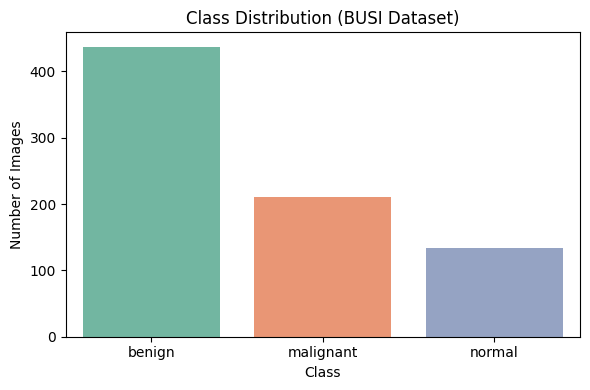

In [4]:
counts = df["label"].value_counts()
print(counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, palette="Set2")
plt.title("Class Distribution (BUSI Dataset)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

**The dataset is imbalanced. Benign has the most samples, Normal the least. We will address this later.**

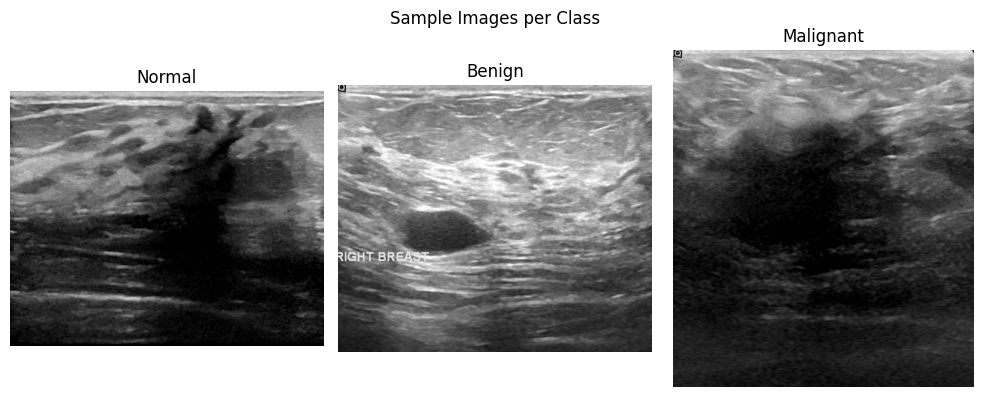

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4))
for i, cls in enumerate(CLASS_NAMES):
    img_path = df[df["label"] == cls].iloc[0]["path"]
    img = Image.open(img_path)
    axes[i].imshow(img, cmap="gray")
    axes[i].set_title(cls.capitalize())
    axes[i].axis("off")
plt.suptitle("Sample Images per Class")
plt.tight_layout()
plt.show()

In [6]:
label_map = {"normal": 0, "benign": 1, "malignant": 2}
df["label_id"] = df["label"].map(label_map)

# 70 / 15 / 15 stratified split
train_df, temp_df = train_test_split(
    df, test_size=0.30, stratify=df["label_id"], random_state=0
)

val_df, test_df = train_test_split(
    temp_df, test_size=0.50, stratify=temp_df["label_id"], random_state=0
)

print(f"Train: {len(train_df)}    Val: {len(val_df)}    Test: {len(test_df)}")
print("\nTrain class distribution:")
print(train_df["label"].value_counts())

Train: 546    Val: 117    Test: 117

Train class distribution:
label
benign       306
malignant    147
normal        93
Name: count, dtype: int64


## Transforms

In [7]:
# used for val / test and plain training runs
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# Augmented transform it is used for the augmentation experiment
aug_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

## Dataset Class

In [8]:
class BUSIDataset(Dataset):

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_path = self.df.iloc[idx]["path"]
        label = self.df.iloc[idx]["label_id"]

        img = Image.open(img_path).convert("RGB")
        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

## DataLoaders

In [9]:
BATCH = 32

train_ds = BUSIDataset(train_df, transform)
train_ds_aug = BUSIDataset(train_df, aug_transform)
val_ds = BUSIDataset(val_df, transform)
test_ds = BUSIDataset(test_df, transform)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH, shuffle=False, num_workers=2)


In [10]:
# Weighted sampler (oversampling)
cls_counts = train_df["label_id"].value_counts().sort_index()
cls_weights = 1.0 / cls_counts
sample_weights = train_df["label_id"].map(cls_weights).values

sampler = WeightedRandomSampler(
    weights = torch.DoubleTensor(sample_weights),
    num_samples = len(sample_weights),
    replacement = True
)

train_loader_os = DataLoader(train_ds, batch_size=BATCH, sampler=sampler, num_workers=2)
train_loader_aug = DataLoader(train_ds_aug, batch_size=BATCH, shuffle=True, num_workers=2)

print("Train class counts:\n", cls_counts)

Train class counts:
 label_id
0     93
1    306
2    147
Name: count, dtype: int64


## Model Blocks

In [11]:
class ConvBNReLU(nn.Module):
    """Standard Conv + BatchNorm + ReLU block."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.block(x)


class DSConv(nn.Module):
    """Depthwise-Separable Conv: depthwise + BatchNorm + ReLU + pointwise + BatchNorm + ReLU."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=1):
        super().__init__()
        self.dw = nn.Conv2d(in_ch, in_ch, kernel, stride=stride, padding=pad, groups=in_ch, bias=False)
        self.dw_bn = nn.BatchNorm2d(in_ch)
        self.pw = nn.Conv2d(in_ch, out_ch, 1, bias=False)
        self.pw_bn = nn.BatchNorm2d(out_ch)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        x = self.act(self.dw_bn(self.dw(x)))
        x = self.act(self.pw_bn(self.pw(x)))
        return x

### Plain CNN (Baseline)

In [12]:
class PlainCNN(nn.Module):
    """Standard CNN baseline using regular convolutions."""
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            ConvBNReLU(3,32), ConvBNReLU(32,32), nn.MaxPool2d(2),
            ConvBNReLU(32,64), ConvBNReLU(64,64), nn.MaxPool2d(2),
            ConvBNReLU(64,128), ConvBNReLU(128,128), nn.MaxPool2d(2),
            ConvBNReLU(128,256),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256,128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128,num_classes)
        )

    def forward(self, x):
        return self.head(self.features(x))

### Depthwise-Separable CNN

In [13]:
class DSCNN(nn.Module):
    """Lightweight CNN replacing all standard convs with depthwise-separable convs."""
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            DSConv(3,32), DSConv(32,32), nn.MaxPool2d(2),
            DSConv(32,64), DSConv(64,64), nn.MaxPool2d(2),
            DSConv(64,128), DSConv(128,128), nn.MaxPool2d(2),
            DSConv(128,256),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256,128), nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(128,num_classes)
        )

    def forward(self, x):
        return self.head(self.features(x))

### Focal Loss

In [14]:
class FocalLoss(nn.Module):
    """Focal Loss down-weights easy examples to focus training on hard ones."""
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(reduction="none")

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.exp(-ce)
        loss = ((1 - pt) ** self.gamma) * ce
        return loss.mean()

## Training & Evaluation Utilities

In [15]:
def train_one_model(model, tr_loader, vl_loader, epochs=25, lr=1e-3, criterion=None):
    model = model.to(device)
    criterion = criterion or nn.CrossEntropyLoss()

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3)

    best_val_acc = 0.0
    best_weights = copy.deepcopy(model.state_dict())

    for epoch in range(1, epochs + 1):
        model.train()
        running_loss, correct, total = 0.0, 0, 0

        for imgs, lbls in tqdm(tr_loader, desc=f"Epoch {epoch:02d}/{epochs}", leave=False):
            imgs, lbls = imgs.to(device), lbls.to(device)

            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, lbls)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            preds = out.argmax(1)
            total += lbls.size(0)
            correct += (preds == lbls).sum().item()

        tr_loss = running_loss / len(tr_loader)
        tr_acc = correct / total

        # validating 
        model.eval()
        v_correct, v_total = 0, 0
        with torch.no_grad():
            for imgs, lbls in vl_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                preds = model(imgs).argmax(1)
                v_total += lbls.size(0)
                v_correct += (preds == lbls).sum().item()

        val_acc = v_correct / v_total
        scheduler.step(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:02d}/{epochs} | Loss: {tr_loss:.4f} | Train Acc: {tr_acc:.4f} | Val Acc: {val_acc:.4f}")
    
    model.load_state_dict(best_weights)
    print(f"\nBest Val Acc: {best_val_acc:.4f}")
    return model

In [16]:
def evaluate(model, loader, class_names=("Normal", "Benign", "Malignant")):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            imgs = imgs.to(device)
            preds = model(imgs).argmax(1)
            y_true.extend(lbls.numpy())
            y_pred.extend(preds.cpu().numpy())

    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))
    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))
    return y_true, y_pred

## Experiments

### Experiment 1: Plain CNN (Baseline)

In [17]:
print("=" * 50)
print(" EXPERIMENT 1 : PLAIN CNN (BASELINE)")
print("=" * 50)

plain_model = PlainCNN(num_classes=3)
plain_model = train_one_model(plain_model, train_loader, val_loader, epochs=25, lr=1e-3, criterion=nn.CrossEntropyLoss())

print("\n--- Test Evaluation ---")
plain_true, plain_pred = evaluate(plain_model, test_loader)

 EXPERIMENT 1 : PLAIN CNN (BASELINE)


Epoch 01/25 | Loss: 0.9611 | Train Acc: 0.5623 | Val Acc: 0.2735


Epoch 02/25 | Loss: 0.9615 | Train Acc: 0.5989 | Val Acc: 0.2821


Epoch 03/25 | Loss: 0.8708 | Train Acc: 0.6264 | Val Acc: 0.6239


Epoch 04/25 | Loss: 0.9169 | Train Acc: 0.6374 | Val Acc: 0.4957


...

Epoch 21/25 | Loss: 0.5989 | Train Acc: 0.7582 | Val Acc: 0.7607


Epoch 22/25 | Loss: 0.6060 | Train Acc: 0.7967 | Val Acc: 0.7521


Epoch 23/25 | Loss: 0.5993 | Train Acc: 0.7564 | Val Acc: 0.5556


Epoch 24/25 | Loss: 0.5994 | Train Acc: 0.7381 | Val Acc: 0.7436


Epoch 25/25 | Loss: 0.5726 | Train Acc: 0.7546 | Val Acc: 0.4957

Best Val Acc: 0.7607

--- Test Evaluation ---
              precision    recall  f1-score   support

      Normal       0.80      0.40      0.53        20
      Benign       0.73      0.94      0.82        66
   Malignant       0.86      0.61      0.72        31

    accuracy                           0.76       117
   macro avg       0.80      0.65      0.69       117
weighted avg       0.78      0.76      0.74       117

Confusion Matrix:
[[ 8 11  1]
 [ 2 62  2]
 [ 0 12 19]]


### Experiment 2: Depthwise-Separable CNN

In [18]:
print("=" * 50)
print(" EXPERIMENT 2 : DEPTHWISE-SEPARABLE CNN")
print("=" * 50)

ds_model = DSCNN(num_classes=3)
ds_model = train_one_model(ds_model, train_loader, val_loader, epochs=25, lr=1e-3, criterion=nn.CrossEntropyLoss())

print("\n--- Test Evaluation ---")
ds_true, ds_pred = evaluate(ds_model, test_loader)

 EXPERIMENT 2 : DEPTHWISE-SEPARABLE CNN


Epoch 01/25 | Loss: 0.9505 | Train Acc: 0.5403 | Val Acc: 0.2735


Epoch 02/25 | Loss: 0.9143 | Train Acc: 0.5879 | Val Acc: 0.2735


Epoch 03/25 | Loss: 0.9286 | Train Acc: 0.6044 | Val Acc: 0.5299


Epoch 04/25 | Loss: 0.8555 | Train Acc: 0.6465 | Val Acc: 0.6410


...

Epoch 21/25 | Loss: 0.4676 | Train Acc: 0.9048 | Val Acc: 0.7692


Epoch 22/25 | Loss: 0.2674 | Train Acc: 0.9249 | Val Acc: 0.7350


Epoch 23/25 | Loss: 0.2406 | Train Acc: 0.9322 | Val Acc: 0.7179


Epoch 24/25 | Loss: 0.2670 | Train Acc: 0.9286 | Val Acc: 0.7778


Epoch 25/25 | Loss: 0.2407 | Train Acc: 0.9322 | Val Acc: 0.7607

Best Val Acc: 0.7949

--- Test Evaluation ---
              precision    recall  f1-score   support

      Normal       0.62      0.80      0.70        20
      Benign       0.81      0.77      0.79        66
   Malignant       0.75      0.68      0.71        31

    accuracy                           0.75       117
   macro avg       0.72      0.75      0.73       117
weighted avg       0.76      0.75      0.75       117

Confusion Matrix:
[[16  2  2]
 [10 51  5]
 [ 0 10 21]]


### Experiment 3: DS-CNN + Weighted Oversampling

In [19]:
print("=" * 50)
print(" EXPERIMENT 3 : DS-CNN + OVERSAMPLING")
print("=" * 50)


ds_os_model = DSCNN(num_classes=3)
ds_os_model = train_one_model(ds_os_model, train_loader_os, val_loader, epochs=25, lr=1e-3, criterion=nn.CrossEntropyLoss())

print("\n--- Test Evaluation ---")
ds_os_true, ds_os_pred = evaluate(ds_os_model, test_loader)

 EXPERIMENT 3 : DS-CNN + OVERSAMPLING


Epoch 01/25 | Loss: 1.0859 | Train Acc: 0.3883 | Val Acc: 0.5556


Epoch 02/25 | Loss: 1.0736 | Train Acc: 0.4304 | Val Acc: 0.2735


Epoch 03/25 | Loss: 1.0539 | Train Acc: 0.5165 | Val Acc: 0.2735


Epoch 04/25 | Loss: 0.9667 | Train Acc: 0.5311 | Val Acc: 0.4017


...

Epoch 21/25 | Loss: 0.4827 | Train Acc: 0.8443 | Val Acc: 0.7265


Epoch 22/25 | Loss: 0.4302 | Train Acc: 0.8608 | Val Acc: 0.7094


Epoch 23/25 | Loss: 0.3928 | Train Acc: 0.8681 | Val Acc: 0.6838


Epoch 24/25 | Loss: 0.5295 | Train Acc: 0.8407 | Val Acc: 0.7009


Epoch 25/25 | Loss: 0.4056 | Train Acc: 0.8553 | Val Acc: 0.6923

Best Val Acc: 0.7265

--- Test Evaluation ---
              precision    recall  f1-score   support

      Normal       0.41      0.35      0.38        20
      Benign       0.75      0.71      0.73        66
   Malignant       0.65      0.77      0.71        31

    accuracy                           0.67       117
   macro avg       0.60      0.61      0.60       117
weighted avg       0.66      0.67      0.66       117

Confusion Matrix:
[[ 7 10  3]
 [ 9 47 10]
 [ 1  6 24]]


### Experiment 4: DS-CNN + Data Augmentation

In [20]:
print("=" * 50)
print(" EXPERIMENT 4 : DS-CNN + AUGMENTATION")
print("=" * 50)

ds_aug_model = DSCNN(num_classes=3)
ds_aug_model = train_one_model(ds_aug_model, train_loader_aug, val_loader, epochs=25, lr=1e-3, criterion=nn.CrossEntropyLoss())

print("\n--- Test Evaluation ---")
ds_aug_true, ds_aug_pred = evaluate(ds_aug_model, test_loader)

 EXPERIMENT 4 : DS-CNN + AUGMENTATION


Epoch 01/25 | Loss: 0.9701 | Train Acc: 0.5476 | Val Acc: 0.2735


Epoch 02/25 | Loss: 0.9366 | Train Acc: 0.5696 | Val Acc: 0.2735


Epoch 03/25 | Loss: 0.9714 | Train Acc: 0.5788 | Val Acc: 0.4274


Epoch 04/25 | Loss: 0.9281 | Train Acc: 0.5751 | Val Acc: 0.6923


...

Epoch 21/25 | Loss: 0.6955 | Train Acc: 0.7473 | Val Acc: 0.7009


Epoch 22/25 | Loss: 0.6207 | Train Acc: 0.7289 | Val Acc: 0.7692


Epoch 23/25 | Loss: 0.6023 | Train Acc: 0.7399 | Val Acc: 0.6581


Epoch 24/25 | Loss: 0.6760 | Train Acc: 0.7289 | Val Acc: 0.7521


Epoch 25/25 | Loss: 0.5831 | Train Acc: 0.7399 | Val Acc: 0.7521

Best Val Acc: 0.7778

--- Test Evaluation ---
              precision    recall  f1-score   support

      Normal       0.67      0.50      0.57        20
      Benign       0.82      0.83      0.83        66
   Malignant       0.74      0.84      0.79        31

    accuracy                           0.78       117
   macro avg       0.74      0.72      0.73       117
weighted avg       0.77      0.78      0.77       117

Confusion Matrix:
[[10  8  2]
 [ 4 55  7]
 [ 1  4 26]]


### Experiment 5: DS-CNN + Focal Loss

In [21]:
print("=" * 50)
print(" EXPERIMENT 5 : DS-CNN + FOCAL LOSS")
print("=" * 50)

ds_fl_model = DSCNN(num_classes=3)
ds_fl_model = train_one_model(ds_fl_model, train_loader, val_loader, epochs=25, lr=1e-3, criterion=FocalLoss(gamma=2.0))

print("\n--- Test Evaluation ---")
ds_fl_true, ds_fl_pred = evaluate(ds_fl_model, test_loader)

 EXPERIMENT 5 : DS-CNN + FOCAL LOSS


Epoch 01/25 | Loss: 0.4453 | Train Acc: 0.5055 | Val Acc: 0.2735


Epoch 02/25 | Loss: 0.4204 | Train Acc: 0.5751 | Val Acc: 0.2735


Epoch 03/25 | Loss: 0.4007 | Train Acc: 0.5604 | Val Acc: 0.3846


Epoch 04/25 | Loss: 0.3784 | Train Acc: 0.5989 | Val Acc: 0.5983


...

Epoch 21/25 | Loss: 0.1416 | Train Acc: 0.7930 | Val Acc: 0.5641


Epoch 22/25 | Loss: 0.1599 | Train Acc: 0.8352 | Val Acc: 0.6581


Epoch 23/25 | Loss: 0.1947 | Train Acc: 0.7766 | Val Acc: 0.6752


Epoch 24/25 | Loss: 0.1346 | Train Acc: 0.8168 | Val Acc: 0.7778


Epoch 25/25 | Loss: 0.1415 | Train Acc: 0.8297 | Val Acc: 0.7265

Best Val Acc: 0.7863

--- Test Evaluation ---
              precision    recall  f1-score   support

      Normal       0.55      0.55      0.55        20
      Benign       0.84      0.77      0.80        66
   Malignant       0.75      0.87      0.81        31

    accuracy                           0.76       117
   macro avg       0.71      0.73      0.72       117
weighted avg       0.76      0.76      0.76       117

Confusion Matrix:
[[11  6  3]
 [ 9 51  6]
 [ 0  4 27]]


## Final Comparison

In [22]:
summary = pd.DataFrame({
    "Method": [
        "Plain CNN",
        "DS-CNN",
        "DS-CNN + Oversampling",
        "DS-CNN + Augmentation",
        "DS-CNN + Focal Loss",
    ],
    "Accuracy": [
        accuracy_score(plain_true,  plain_pred),
        accuracy_score(ds_true,     ds_pred),
        accuracy_score(ds_os_true,  ds_os_pred),
        accuracy_score(ds_aug_true, ds_aug_pred),
        accuracy_score(ds_fl_true,  ds_fl_pred),
    ],
    "F1 (weighted)": [
        f1_score(plain_true,  plain_pred,  average="weighted"),
        f1_score(ds_true,     ds_pred,     average="weighted"),
        f1_score(ds_os_true,  ds_os_pred,  average="weighted"),
        f1_score(ds_aug_true, ds_aug_pred, average="weighted"),
        f1_score(ds_fl_true,  ds_fl_pred,  average="weighted"),
    ]
})

print(summary.sort_values("F1 (weighted)", ascending=False).reset_index(drop=True).to_string(index=False))

               Method  Accuracy  F1 (weighted)
DS-CNN + Augmentation  0.777778       0.772985
  DS-CNN + Focal Loss  0.760684       0.760623
               DS-CNN  0.752137       0.753563
            Plain CNN  0.760684       0.744374
DS-CNN + Oversampling  0.666667       0.662760


/tmp/ipykernel_55/2681355425.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_sorted, x="Method", y="Accuracy", palette="Blues_d", ax=axes[0])
/tmp/ipykernel_55/2681355425.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
/tmp/ipykernel_55/2681355425.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary_sorted, x="Method", y="F1 (weighted)", palette="Greens_d", ax=axes[1])
/tmp/ipykernel_55/2681355425.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_t

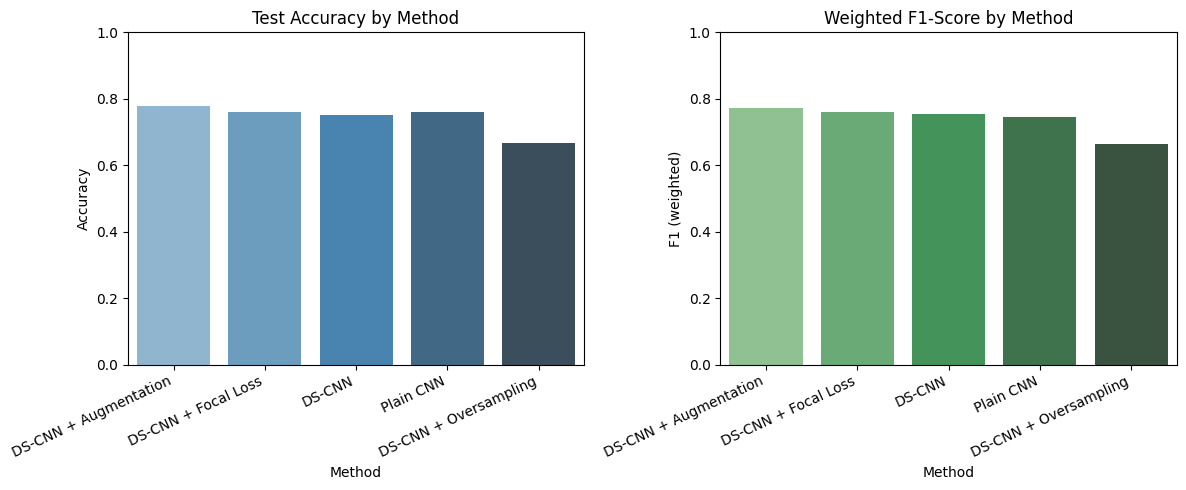

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

summary_sorted = summary.sort_values("F1 (weighted)", ascending=False)

sns.barplot(data=summary_sorted, x="Method", y="Accuracy", palette="Blues_d", ax=axes[0])
axes[0].set_title("Test Accuracy by Method")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=25, ha="right")
axes[0].set_ylim(0, 1)

sns.barplot(data=summary_sorted, x="Method", y="F1 (weighted)", palette="Greens_d", ax=axes[1])
axes[1].set_title("Weighted F1-Score by Method")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=25, ha="right")
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()